<a href="https://colab.research.google.com/github/Aravi9272/Wildlife_image_classification_CNN/blob/main/Wildlife_image_classification_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q torchinfo

In [ ]:
import os
import sys
from collections import Counter

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
from torchvision import datasets, transforms
from tqdm.notebook import tqdm

torch.backends.cudnn.deterministic = True

In [ ]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device.")

Using cuda device.


In [ ]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")
print("matplotlib version:", matplotlib.__version__)
print("pandas version:", pd.__version__)
print("PIL version:", PIL.__version__)
print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

Platform: linux
Python version: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
---
matplotlib version: 3.10.0
pandas version: 2.2.2
PIL version: 11.3.0
torch version: 2.6.0+cu124
torchvision version: 0.21.0+cu124


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/My Drive/wildlife_hog.zip" -d "/content/wildlife_hog"

Archive:  /content/drive/My Drive/wildlife_hog.zip
  inflating: /content/wildlife_hog/ZJ012491.jpg  
  inflating: /content/wildlife_hog/ZJ008633.jpg  
  inflating: /content/wildlife_hog/ZJ012697.jpg  
  inflating: /content/wildlife_hog/ZJ002467.jpg  
  inflating: /content/wildlife_hog/ZJ010219.jpg  
  inflating: /content/wildlife_hog/ZJ001613.jpg  
  inflating: /content/wildlife_hog/ZJ003495.jpg  
  inflating: /content/wildlife_hog/ZJ008757.jpg  
  inflating: /content/wildlife_hog/ZJ013422.jpg  
  inflating: /content/wildlife_hog/ZJ007016.jpg  
  inflating: /content/wildlife_hog/ZJ004997.jpg  
  inflating: /content/wildlife_hog/ZJ014107.jpg  
  inflating: /content/wildlife_hog/ZJ010565.jpg  
  inflating: /content/wildlife_hog/ZJ006139.jpg  
  inflating: /content/wildlife_hog/ZJ010198.jpg  
  inflating: /content/wildlife_hog/ZJ015735.jpg  
  inflating: /content/wildlife_hog/ZJ016295.jpg  
  inflating: /content/wildlife_hog/ZJ006259.jpg  
  inflating: /content/wildlife_hog/ZJ003962.jpg  

In [ ]:
!unzip "/content/drive/My Drive/wildlife_monkey.zip" -d "/content/wildlife_monkey"

Archive:  /content/drive/My Drive/wildlife_monkey.zip
  inflating: /content/wildlife_monkey/ZJ004398.jpg  
  inflating: /content/wildlife_monkey/ZJ013192.jpg  
  inflating: /content/wildlife_monkey/ZJ003858.jpg  
  inflating: /content/wildlife_monkey/ZJ009759.jpg  
  inflating: /content/wildlife_monkey/ZJ000927.jpg  
  inflating: /content/wildlife_monkey/ZJ002779.jpg  
  inflating: /content/wildlife_monkey/ZJ003591.jpg  
  inflating: /content/wildlife_monkey/ZJ010019.jpg  
  inflating: /content/wildlife_monkey/ZJ010652.jpg  
  inflating: /content/wildlife_monkey/ZJ008090.jpg  
  inflating: /content/wildlife_monkey/ZJ010006.jpg  
  inflating: /content/wildlife_monkey/ZJ014147.jpg  
  inflating: /content/wildlife_monkey/ZJ008307.jpg  
  inflating: /content/wildlife_monkey/ZJ000658.jpg  
  inflating: /content/wildlife_monkey/ZJ005825.jpg  
  inflating: /content/wildlife_monkey/ZJ001333.jpg  
  inflating: /content/wildlife_monkey/ZJ000347.jpg  
  inflating: /content/wildlife_monkey/ZJ00837

In [ ]:
!unzip "/content/drive/My Drive/wildlife_leopard.zip" -d "/content/wildlife_leopard"

Archive:  /content/drive/My Drive/wildlife_leopard.zip
  inflating: /content/wildlife_leopard/ZJ004954.jpg  
  inflating: /content/wildlife_leopard/ZJ014334.jpg  
  inflating: /content/wildlife_leopard/ZJ012931.jpg  
  inflating: /content/wildlife_leopard/ZJ014505.jpg  
  inflating: /content/wildlife_leopard/ZJ008604.jpg  
  inflating: /content/wildlife_leopard/ZJ008707.jpg  
  inflating: /content/wildlife_leopard/ZJ006454.jpg  
  inflating: /content/wildlife_leopard/ZJ009441.jpg  
  inflating: /content/wildlife_leopard/ZJ009010.jpg  
  inflating: /content/wildlife_leopard/ZJ016404.jpg  
  inflating: /content/wildlife_leopard/ZJ016303.jpg  
  inflating: /content/wildlife_leopard/ZJ000888.jpg  
  inflating: /content/wildlife_leopard/ZJ015680.jpg  
  inflating: /content/wildlife_leopard/ZJ011189.jpg  
  inflating: /content/wildlife_leopard/ZJ011607.jpg  
  inflating: /content/wildlife_leopard/ZJ002920.jpg  
  inflating: /content/wildlife_leopard/ZJ012758.jpg  
  inflating: /content/wildl

In [ ]:
!unzip "/content/drive/My Drive/wildlife_civetgenet.zip" -d "/content/wildlife_civetgenet"

Archive:  /content/drive/My Drive/wildlife_civetgenet.zip
  inflating: /content/wildlife_civetgenet/ZJ001133.jpg  
  inflating: /content/wildlife_civetgenet/ZJ016166.jpg  
  inflating: /content/wildlife_civetgenet/ZJ011941.jpg  
  inflating: /content/wildlife_civetgenet/ZJ015764.jpg  
  inflating: /content/wildlife_civetgenet/ZJ012153.jpg  
  inflating: /content/wildlife_civetgenet/ZJ008417.jpg  
  inflating: /content/wildlife_civetgenet/ZJ015307.jpg  
  inflating: /content/wildlife_civetgenet/ZJ011293.jpg  
  inflating: /content/wildlife_civetgenet/ZJ016206.jpg  
  inflating: /content/wildlife_civetgenet/ZJ013606.jpg  
  inflating: /content/wildlife_civetgenet/ZJ014516.jpg  
  inflating: /content/wildlife_civetgenet/ZJ016269.jpg  
  inflating: /content/wildlife_civetgenet/ZJ013777.jpg  
  inflating: /content/wildlife_civetgenet/ZJ001221.jpg  
  inflating: /content/wildlife_civetgenet/ZJ002946.jpg  
  inflating: /content/wildlife_civetgenet/ZJ013133.jpg  
  inflating: /content/wildlife

In [ ]:
!unzip "/content/drive/My Drive/wildlife_antelope_duikers.zip" -d "/content/wildlife_antelope_duikers"

Archive:  /content/drive/My Drive/wildlife_antelope_duikers.zip
   creating: /content/wildlife_antelope_duikers/antelope duikers/
  inflating: /content/wildlife_antelope_duikers/antelope duikers/ZJ000007.jpg  
  inflating: /content/wildlife_antelope_duikers/antelope duikers/ZJ000022.jpg  
  inflating: /content/wildlife_antelope_duikers/antelope duikers/ZJ000030.jpg  
  inflating: /content/wildlife_antelope_duikers/antelope duikers/ZJ000037.jpg  
  inflating: /content/wildlife_antelope_duikers/antelope duikers/ZJ000039.jpg  
  inflating: /content/wildlife_antelope_duikers/antelope duikers/ZJ000043.jpg  
  inflating: /content/wildlife_antelope_duikers/antelope duikers/ZJ000049.jpg  
  inflating: /content/wildlife_antelope_duikers/antelope duikers/ZJ000057.jpg  
  inflating: /content/wildlife_antelope_duikers/antelope duikers/ZJ000065.jpg  
  inflating: /content/wildlife_antelope_duikers/antelope duikers/ZJ000067.jpg  
  inflating: /content/wildlife_antelope_duikers/antelope duikers/ZJ000

In [ ]:
!unzip "/content/drive/My Drive/wildlife_rodent.zip" -d "/content/wildlife_rodent"

Archive:  /content/drive/My Drive/wildlife_rodent.zip
  inflating: /content/wildlife_rodent/ZJ010883.jpg  
  inflating: /content/wildlife_rodent/ZJ014078.jpg  
  inflating: /content/wildlife_rodent/ZJ010884.jpg  
  inflating: /content/wildlife_rodent/ZJ010067.jpg  
  inflating: /content/wildlife_rodent/ZJ000035.jpg  
  inflating: /content/wildlife_rodent/ZJ005429.jpg  
  inflating: /content/wildlife_rodent/ZJ012830.jpg  
  inflating: /content/wildlife_rodent/ZJ007036.jpg  
  inflating: /content/wildlife_rodent/ZJ005997.jpg  
  inflating: /content/wildlife_rodent/ZJ009248.jpg  
  inflating: /content/wildlife_rodent/ZJ013742.jpg  
  inflating: /content/wildlife_rodent/ZJ013522.jpg  
  inflating: /content/wildlife_rodent/ZJ015511.jpg  
  inflating: /content/wildlife_rodent/ZJ006959.jpg  
  inflating: /content/wildlife_rodent/ZJ013181.jpg  
  inflating: /content/wildlife_rodent/ZJ009918.jpg  
  inflating: /content/wildlife_rodent/ZJ008067.jpg  
  inflating: /content/wildlife_rodent/ZJ00374

In [ ]:
!unzip "/content/drive/My Drive/wildlife_birds.zip" -d "/content/wildlife_birds"

Archive:  /content/drive/My Drive/wildlife_birds.zip
   creating: /content/wildlife_birds/birds/
  inflating: /content/wildlife_birds/birds/ZJ000000.jpg  
  inflating: /content/wildlife_birds/birds/ZJ000002.jpg  
  inflating: /content/wildlife_birds/birds/ZJ000009.jpg  
  inflating: /content/wildlife_birds/birds/ZJ000017.jpg  
  inflating: /content/wildlife_birds/birds/ZJ000060.jpg  
  inflating: /content/wildlife_birds/birds/ZJ000071.jpg  
  inflating: /content/wildlife_birds/birds/ZJ000074.jpg  
  inflating: /content/wildlife_birds/birds/ZJ000079.jpg  
  inflating: /content/wildlife_birds/birds/ZJ000081.jpg  
  inflating: /content/wildlife_birds/birds/ZJ000087.jpg  
  inflating: /content/wildlife_birds/birds/ZJ000092.jpg  
  inflating: /content/wildlife_birds/birds/ZJ000114.jpg  
  inflating: /content/wildlife_birds/birds/ZJ000125.jpg  
  inflating: /content/wildlife_birds/birds/ZJ000129.jpg  
  inflating: /content/wildlife_birds/birds/ZJ000154.jpg  
  inflating: /content/wildlife_bi

In [ ]:
!unzip "/content/drive/My Drive/wildlife_blank.zip" -d "/content/wildlife_blank"

Archive:  /content/drive/My Drive/wildlife_blank.zip
  inflating: /content/wildlife_blank/ZJ016009.jpg  
  inflating: /content/wildlife_blank/ZJ001885.jpg  
  inflating: /content/wildlife_blank/ZJ008551.jpg  
  inflating: /content/wildlife_blank/ZJ006028.jpg  
  inflating: /content/wildlife_blank/ZJ005917.jpg  
  inflating: /content/wildlife_blank/ZJ010962.jpg  
  inflating: /content/wildlife_blank/ZJ008061.jpg  
  inflating: /content/wildlife_blank/ZJ004381.jpg  
  inflating: /content/wildlife_blank/ZJ007359.jpg  
  inflating: /content/wildlife_blank/ZJ004984.jpg  
  inflating: /content/wildlife_blank/ZJ005509.jpg  
  inflating: /content/wildlife_blank/ZJ012231.jpg  
  inflating: /content/wildlife_blank/ZJ011672.jpg  
  inflating: /content/wildlife_blank/ZJ013221.jpg  
  inflating: /content/wildlife_blank/ZJ013265.jpg  
  inflating: /content/wildlife_blank/ZJ005502.jpg  
  inflating: /content/wildlife_blank/ZJ007396.jpg  
  inflating: /content/wildlife_blank/ZJ014860.jpg  
  inflating

In [ ]:
!unzip "/content/drive/My Drive/test_features.zip" -d "/content/test"

Archive:  /content/drive/My Drive/test_features.zip
  inflating: /content/test/ZJ017787.jpg  
  inflating: /content/test/ZJ019093.jpg  
  inflating: /content/test/ZJ019193.jpg  
  inflating: /content/test/ZJ019108.jpg  
  inflating: /content/test/ZJ017779.jpg  
  inflating: /content/test/ZJ020487.jpg  
  inflating: /content/test/ZJ020471.jpg  
  inflating: /content/test/ZJ019491.jpg  
  inflating: /content/test/ZJ016813.jpg  
  inflating: /content/test/ZJ019882.jpg  
  inflating: /content/test/ZJ016520.jpg  
  inflating: /content/test/ZJ016689.jpg  
  inflating: /content/test/ZJ017094.jpg  
  inflating: /content/test/ZJ018422.jpg  
  inflating: /content/test/ZJ020546.jpg  
  inflating: /content/test/ZJ018302.jpg  
  inflating: /content/test/ZJ019470.jpg  
  inflating: /content/test/ZJ019371.jpg  
  inflating: /content/test/ZJ017654.jpg  
  inflating: /content/test/ZJ017846.jpg  
  inflating: /content/test/ZJ019991.jpg  
  inflating: /content/test/ZJ018896.jpg  
  inflating: /content/te

In [ ]:
import os
print(os.listdir("/content"))


['.config', 'wildlife_blank', 'wildlife_antelope_duikers', 'wildlife_rodent', 'wildlife_monkey', 'wildlife_hog', 'wildlife_birds', 'wildlife_civetgenet', 'wildlife_leopard', 'test', 'drive', 'sample_data']


In [ ]:
import os
import shutil

# Step 1: Create root directory structure
root_dir = "/content/data/data_multiclass"
train_dir = os.path.join(root_dir, "train")
test_dir = os.path.join(root_dir, "test")
test_features_dir = os.path.join(test_dir, "test_features")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)
os.makedirs(test_features_dir, exist_ok=True)

# Step 2: Create class subdirectories inside train/
class_dirs = {
    "hog": os.path.join(train_dir, "wildlife_hog"),
    "blank": os.path.join(train_dir, "wildlife_blank"),
    "leopard": os.path.join(train_dir, "wildlife_leopard"),
    "monkey": os.path.join(train_dir, "wildlife_monkey"),
    "birds": os.path.join(train_dir, "wildlife_birds"),
    "civetgenet": os.path.join(train_dir, "wildlife_civetgenet"),
    "antelope_duikers": os.path.join(train_dir, "wildlife_antelope_duikers"),
    "rodent": os.path.join(train_dir, "wildlife_rodent")
}

for path in class_dirs.values():
    os.makedirs(path, exist_ok=True)

# Step 3: Copy images into their respective class folders

# hog
for filename in os.listdir("/content/wildlife_hog"):
    src = os.path.join("/content/wildlife_hog", filename)
    dst = os.path.join(class_dirs["hog"], filename)
    shutil.copy2(src, dst)

# blank
for filename in os.listdir("/content/wildlife_blank"):
    src = os.path.join("/content/wildlife_blank", filename)
    dst = os.path.join(class_dirs["blank"], filename)
    shutil.copy2(src, dst)

# leopard
for filename in os.listdir("/content/wildlife_leopard"):
    src = os.path.join("/content/wildlife_leopard", filename)
    dst = os.path.join(class_dirs["leopard"], filename)
    shutil.copy2(src, dst)

# monkey
for filename in os.listdir("/content/wildlife_monkey"):
    src = os.path.join("/content/wildlife_monkey", filename)
    dst = os.path.join(class_dirs["monkey"], filename)
    shutil.copy2(src, dst)

# birds (nested inside birds/)
for filename in os.listdir("/content/wildlife_birds/birds"):
    src = os.path.join("/content/wildlife_birds/birds", filename)
    dst = os.path.join(class_dirs["birds"], filename)
    shutil.copy2(src, dst)

# civetgenet
for filename in os.listdir("/content/wildlife_civetgenet"):
    src = os.path.join("/content/wildlife_civetgenet", filename)
    dst = os.path.join(class_dirs["civetgenet"], filename)
    shutil.copy2(src, dst)

# antelope_duikers (nested inside antelope duikers/)
for filename in os.listdir("/content/wildlife_antelope_duikers/antelope duikers"):
    src = os.path.join("/content/wildlife_antelope_duikers/antelope duikers", filename)
    dst = os.path.join(class_dirs["antelope_duikers"], filename)
    shutil.copy2(src, dst)

# rodent
for filename in os.listdir("/content/wildlife_rodent"):
    src = os.path.join("/content/wildlife_rodent", filename)
    dst = os.path.join(class_dirs["rodent"], filename)
    shutil.copy2(src, dst)

# Step 4: Copy test images into testdata/
test_img_dir = "/content/test"
for filename in os.listdir(test_img_dir):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        src = os.path.join(test_img_dir, filename)
        dst = os.path.join(test_features_dir, filename)
        shutil.copy2(src, dst)

# Step 5: Copy CSV files into test/
csv_files = ["submission_format.csv", "test_features.csv"]
for csv_file in csv_files:
    src = os.path.join("/content", csv_file)
    dst = os.path.join(test_dir, csv_file)
    if os.path.exists(src):
        shutil.copy2(src, dst)
    else:
        print(f"⚠️ CSV file missing: {csv_file}")


⚠️ CSV file missing: submission_format.csv
⚠️ CSV file missing: test_features.csv


In [ ]:


train_dir = os.path.join(root_dir, 'train')


print("Will read data from", train_dir)

Will read data from /content/data/data_multiclass/train


In [ ]:
labels = os.listdir(train_dir)
labels

['wildlife_rodent',
 'wildlife_birds',
 'wildlife_civetgenet',
 'wildlife_leopard',
 'wildlife_hog',
 'wildlife_monkey',
 'wildlife_blank',
 'wildlife_antelope_duikers']

In [ ]:
hog_path = os.path.join(train_dir, "wildlife_hog")
hog_images = os.listdir(hog_path)
print("length of hog images: ", len(hog_images))

blank_path = os.path.join(train_dir, "wildlife_blank")
blank_images = os.listdir(blank_path)
print("length of blank images: ", len(blank_images))

leopard_path = os.path.join(train_dir, "wildlife_leopard")
leopard_images = os.listdir(leopard_path)
print("length of leopard images: ", len(leopard_images))

monkey_path = os.path.join(train_dir, "wildlife_monkey")
monkey_images = os.listdir(monkey_path)
print("length of monkey images: ", len(monkey_images))

birds_path = os.path.join(train_dir, "wildlife_birds")
birds_images = os.listdir(birds_path)
print("length of birds images: ", len(birds_images))

civetgenet_path = os.path.join(train_dir, "wildlife_civetgenet")
civetgenet_images = os.listdir(civetgenet_path)
print("length of civetgenet images: ", len(civetgenet_images))

antelope_duikers_path = os.path.join(train_dir, "wildlife_antelope_duikers")
antelope_duikers_images = os.listdir(antelope_duikers_path)
print("length of antelope_duikers images: ", len(antelope_duikers_images))

rodent_path = os.path.join(train_dir, "wildlife_rodent")
rodent_images = os.listdir(rodent_path)
print("length of rodent images: ", len(rodent_images))



length of hog images:  978
length of blank images:  2213
length of leopard images:  2254
length of monkey images:  2492
length of birds images:  1641
length of civetgenet images:  2423
length of antelope_duikers images:  2474
length of rodent images:  2013


In [ ]:
class ConvertToRGB:
    def __call__(self, img):
        if img.mode != "RGB":
            img = img.convert("RGB")
        return img

In [ ]:
import timm
from timm import create_model

# Choose EfficientNetB3 or B4
model = create_model('efficientnet_b3', pretrained=True, num_classes=8)
# model = create_model('efficientnet_b4', pretrained=True, num_classes=8)  # optional

model.to(device)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

EfficientNet(
  (conv_stem): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
        (bn1): BatchNormAct2d(
          40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(40, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (b

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    ConvertToRGB(),
    transforms.Resize((300, 300)),  # EfficientNet prefers 300x300
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # Standard ImageNet mean
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

# Replace with your path
train_path = "/content/data/data_multiclass/train"

dataset = ImageFolder(train_path, transform=transform)

g = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(dataset, [0.8, 0.2], generator=g)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)


In [ ]:
from torch.optim import AdamW
optimizer = AdamW(model.parameters(), lr=0.0003, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()


In [ ]:
from tqdm import tqdm
import torch

def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=10):
    train_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        # tqdm for training progress
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Training]", leave=False)
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            loop.set_postfix(loss=loss.item())

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # Validation accuracy
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = correct / total
        val_accuracies.append(val_acc)

        print(f" Epoch {epoch+1}: Loss = {epoch_loss:.4f}, Val Accuracy = {val_acc:.4f}")

    return train_losses, val_accuracies


 Epoch 1: Loss = 0.7644, Val Accuracy = 0.8399


 Epoch 2: Loss = 0.2219, Val Accuracy = 0.8720


 Epoch 3: Loss = 0.1235, Val Accuracy = 0.8869


 Epoch 4: Loss = 0.0991, Val Accuracy = 0.8817


 Epoch 5: Loss = 0.0906, Val Accuracy = 0.8869


 Epoch 6: Loss = 0.0752, Val Accuracy = 0.8793


 Epoch 7: Loss = 0.0783, Val Accuracy = 0.8847


 Epoch 8: Loss = 0.0673, Val Accuracy = 0.8926


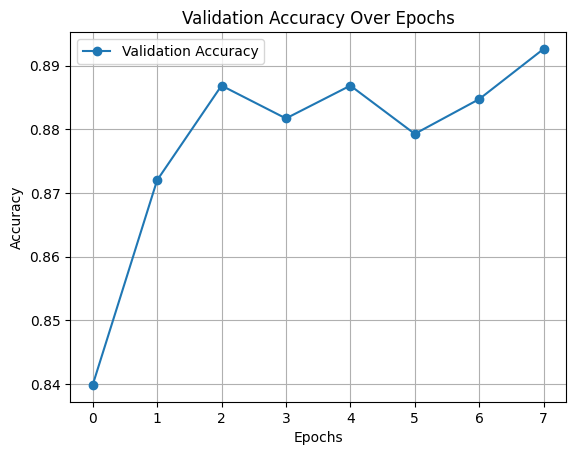

In [ ]:
import matplotlib.pyplot as plt

train_loss, val_acc = train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=8)

plt.plot(val_acc, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Over Epochs")
plt.legend()
plt.grid(True)
plt.show()


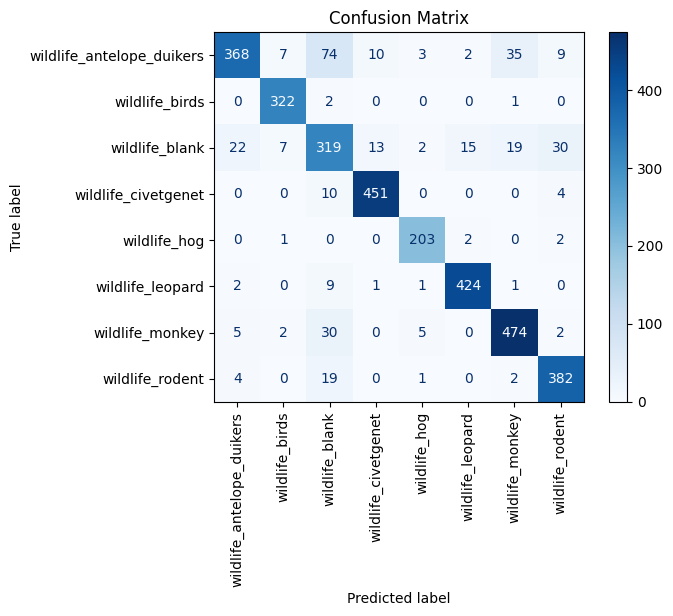

                           precision    recall  f1-score   support

wildlife_antelope_duikers       0.92      0.72      0.81       508
           wildlife_birds       0.95      0.99      0.97       325
           wildlife_blank       0.69      0.75      0.72       427
      wildlife_civetgenet       0.95      0.97      0.96       465
             wildlife_hog       0.94      0.98      0.96       208
         wildlife_leopard       0.96      0.97      0.96       438
          wildlife_monkey       0.89      0.92      0.90       518
          wildlife_rodent       0.89      0.94      0.91       408

                 accuracy                           0.89      3297
                macro avg       0.90      0.90      0.90      3297
             weighted avg       0.90      0.89      0.89      3297



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Get predictions
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes)
disp.plot(cmap="Blues", xticks_rotation="vertical")
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

# Classification Report (F1, Recall, Precision)
print(classification_report(all_labels, all_preds, target_names=dataset.classes))


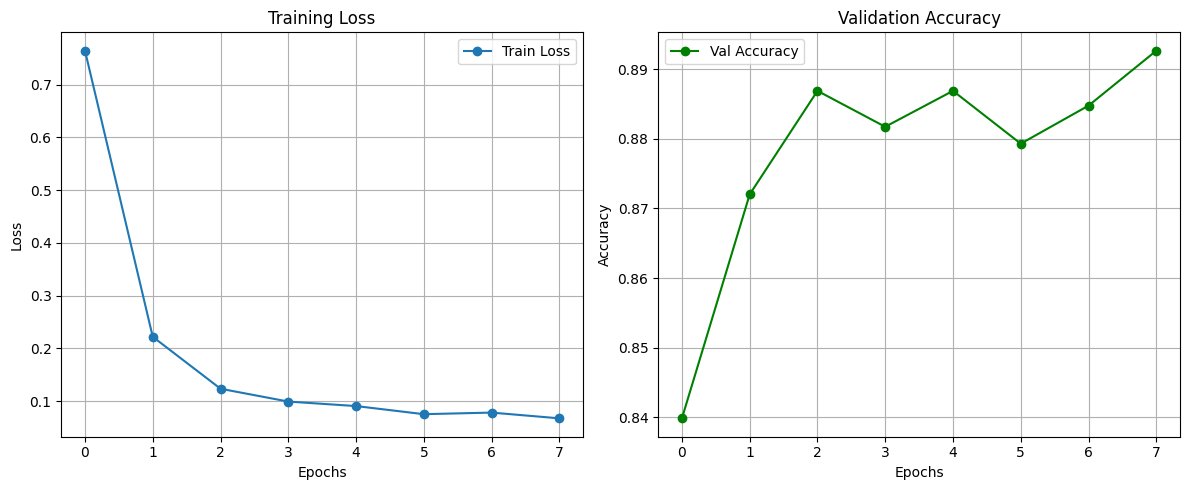

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train Loss', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_acc, label='Val Accuracy', marker='o', color='green')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Save entire model
torch.save(model, "efficient_netb3.pth")

# Copy to Drive
!cp efficient_netb3.pth /content/drive/MyDrive/efficient_netb3.pth


In [ ]:
import torch

model = torch.load("/content/drive/MyDrive/efficient_netb3.pth", weights_only=False)
model.eval().to(device)

EfficientNet(
  (conv_stem): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
        (bn1): BatchNormAct2d(
          40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(40, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (b

In [ ]:
transform = transforms.Compose([
    ConvertToRGB(),
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
from PIL import Image
import torch.nn.functional as F

def predict_single_image(image_path, model, transform, class_names, device):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = F.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_idx].item()

    predicted_class = class_names[pred_idx]
    return predicted_class, confidence


 Predicted Class: wildlife_rodent
 Confidence: 0.7530


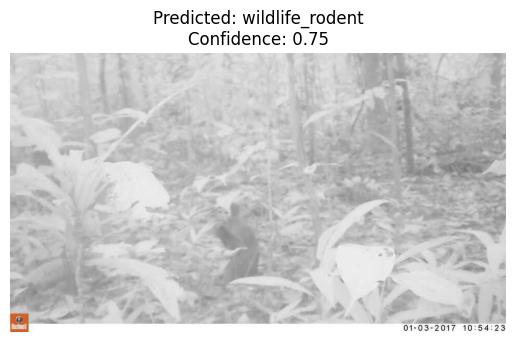

In [ ]:
image_path = "/content/data/data_multiclass/test/test_features/ZJ016930.jpg"

predicted_class, confidence = predict_single_image(
    image_path,
    model,
    transform,
    dataset.classes,
    device
)

print(f" Predicted Class: {predicted_class}")
print(f" Confidence: {confidence:.4f}")


import matplotlib.pyplot as plt

img = Image.open(image_path)
plt.imshow(img)
plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2f}")
plt.axis('off')
plt.show()
